# 高效变体模型训练

默认先快速验证一个数据集、一个预测步长和一个模型，避免一次 notebook 运行卡在超长训练中。需要完整对比时，修改配置单元中的 `DATASETS_TO_RUN`、`HORIZONS_TO_RUN`、`MODELS_TO_RUN`、`FAST_DEV_RUN` 和 `EPOCHS`。

## 1. 环境与依赖

In [1]:
import os
import sys
import time

ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if ROOT not in sys.path:
    sys.path.append(ROOT)

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from models import InformerModel, AutoformerModel, PatchTSTModel, TimeSeriesDataset, Trainer

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'设备: {DEVICE}')


PyTorch: 2.10.0+cu126
CUDA available: True
设备: cuda


## 2. 实验配置

In [ ]:
DATASETS = ['ETTh1', 'ETTm1', 'ECL']
HORIZON_LIST = [24, 48, 96, 168, 336]
MODELS = ['Autoformer', 'Informer', 'PatchTST']

DATASETS_TO_RUN = DATASETS[0:1]
HORIZONS_TO_RUN = HORIZON_LIST[0:2]
MODELS_TO_RUN = MODELS[1:2]

FAST_DEV_RUN = False
SAMPLE_LIMITS = {
    'train': 4096,
    'val': 1024,
    'test': 1024,
}

BATCH_SIZE_BY_DATASET = {
    'ETTh1': 64,
    'ETTm1': 64,
    'ECL': 8,
}
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

SEED = 216
EPOCHS = 3 if FAST_DEV_RUN else 30
PATIENCE = 2 if FAST_DEV_RUN else 6
LEARNING_RATE = 3e-4
DATA_DIR = os.path.join(ROOT, 'data', 'processed')

unknown_datasets = [name for name in DATASETS_TO_RUN if name not in DATASETS]
unknown_horizons = [h for h in HORIZONS_TO_RUN if h not in HORIZON_LIST]
unknown_models = [name for name in MODELS_TO_RUN if name not in MODELS]
if unknown_datasets:
    raise ValueError(f'Unknown datasets: {unknown_datasets}')
if unknown_horizons:
    raise ValueError(f'Unknown horizons: {unknown_horizons}')
if unknown_models:
    raise ValueError(f'Unknown models: {unknown_models}')

if 'ECL' in DATASETS_TO_RUN:
    print('Note: ECL npz files are large. Use a small batch size and consider FAST_DEV_RUN first.')

print(f'Datasets to run: {DATASETS_TO_RUN}')
print(f'Horizons to run: {HORIZONS_TO_RUN}')
print(f'Models to run: {MODELS_TO_RUN}')
print(f'Fast dev run: {FAST_DEV_RUN}')
print(f'Epochs: {EPOCHS}, Patience: {PATIENCE}')
print(f'Learning rate: {LEARNING_RATE}')
print(f'Seed: {SEED}')
print(f'Batch sizes: {BATCH_SIZE_BY_DATASET}')

## 3. 数据加载

In [19]:
def select_even_subset(dataset, limit):
    if limit is None or len(dataset) <= limit:
        return dataset
    indices = np.linspace(0, len(dataset) - 1, num=limit, dtype=np.int64)
    return Subset(dataset, indices.tolist())


def create_experiment_data(dataset_name, horizon):
    batch_size = BATCH_SIZE_BY_DATASET[dataset_name]

    train_dataset = TimeSeriesDataset(DATA_DIR, dataset_name, horizon, 'train')
    val_dataset = TimeSeriesDataset(DATA_DIR, dataset_name, horizon, 'val')
    test_dataset = TimeSeriesDataset(DATA_DIR, dataset_name, horizon, 'test')

    train_data = select_even_subset(train_dataset, SAMPLE_LIMITS['train'] if FAST_DEV_RUN else None)
    val_data = select_even_subset(val_dataset, SAMPLE_LIMITS['val'] if FAST_DEV_RUN else None)
    test_data = select_even_subset(test_dataset, SAMPLE_LIMITS['test'] if FAST_DEV_RUN else None)

    train_loader = DataLoader(
        train_data, batch_size=batch_size, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    val_loader = DataLoader(
        val_data, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )
    test_loader = DataLoader(
        test_data, batch_size=batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
    )

    info = {
        'dataset': dataset_name,
        'horizon': horizon,
        'batch_size': batch_size,
        'train_dataset': train_dataset,
        'val_dataset': val_dataset,
        'test_dataset': test_dataset,
        'train_data': train_data,
        'val_data': val_data,
        'test_data': test_data,
        'train_loader': train_loader,
        'val_loader': val_loader,
        'test_loader': test_loader,
        'input_size': train_dataset.input_size,
        'target_idx': train_dataset.target_idx,
    }

    print()
    print('Data loaded')
    print(f'  Dataset: {dataset_name}, horizon: {horizon}')
    print(f'  Input features: {info["input_size"]}, target index: {info["target_idx"]}')
    print(f'  Train samples: {len(train_data)} / {len(train_dataset)}')
    print(f'  Val samples: {len(val_data)} / {len(val_dataset)}')
    print(f'  Test samples: {len(test_data)} / {len(test_dataset)}')
    print(f'  Batch size: {batch_size}')

    return info


## 4. 模型构建

In [20]:
def build_model(model_name, input_size, horizon):
    small_multivariate = input_size > 32

    if model_name == 'Informer':
        return InformerModel(
            input_size=input_size,
            d_model=64 if not small_multivariate else 32,
            n_heads=4,
            n_encoder_layers=2 if not small_multivariate else 1,
            n_decoder_layers=1,
            d_ff=128 if not small_multivariate else 64,
            factor=3,
            dropout=0.1,
            horizon=horizon,
        )

    if model_name == 'Autoformer':
        return AutoformerModel(
            input_size=input_size,
            d_model=48 if not small_multivariate else 32,
            n_heads=4,
            n_encoder_layers=2 if not small_multivariate else 1,
            n_decoder_layers=1,
            d_ff=96 if not small_multivariate else 64,
            factor=3 if not small_multivariate else 2,
            dropout=0.1,
            horizon=horizon,
            kernel_size=25,
        )

    if model_name == 'PatchTST':
        return PatchTSTModel(
            input_size=input_size,
            d_model=64 if not small_multivariate else 32,
            n_heads=4,
            n_layers=2 if not small_multivariate else 1,
            d_ff=128 if not small_multivariate else 64,
            patch_len=16,
            stride=8,
            dropout=0.1,
            horizon=horizon,
        )

    raise ValueError(f'Unknown model: {model_name}')


## 5. 训练与评估

In [ ]:
results_dir = os.path.join(ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)

all_results = {}
saved_paths = {}
latest_combo_keys = []
latest_predictions = None
latest_targets = None
latest_target_idx = None
latest_horizon = None

for dataset_name in DATASETS_TO_RUN:
    for horizon in HORIZONS_TO_RUN:
        print()
        print('#' * 80)
        print(f'Experiment: dataset={dataset_name}, horizon={horizon}')
        print('#' * 80)

        data_info = create_experiment_data(dataset_name, horizon)
        models = {
            name: build_model(name, data_info['input_size'], horizon)
            for name in MODELS_TO_RUN
        }

        for name, model in models.items():
            params = sum(p.numel() for p in model.parameters())
            print(f'{name} parameters: {params:,}')

        latest_combo_keys = []

        for model_name, model in models.items():
            print()
            print('=' * 80)
            print(f'Training {model_name} | dataset={dataset_name} | horizon={horizon}')
            print('=' * 80)

            trainer = Trainer(model, device=DEVICE, lr=LEARNING_RATE, seed=SEED)
            start_time = time.time()
            history = trainer.train(
                data_info['train_loader'], data_info['val_loader'],
                epochs=EPOCHS,
                patience=PATIENCE,
                save_dir=os.path.join(ROOT, 'checkpoints'),
                model_name=f'{model_name}_{dataset_name}_h{horizon}',
                log_dir=os.path.join(ROOT, 'runs', model_name),
            )
            elapsed = time.time() - start_time

            preds, tgts = trainer.predict(data_info['test_loader'])
            model_metrics = trainer.compute_metrics(preds, tgts, data_info['target_idx'])

            val_losses = history['val_losses']
            trained_epochs = len(history['train_losses'])
            best_epoch = int(np.argmin(val_losses)) + 1 if val_losses else None
            result_key = f'{dataset_name}_h{horizon}_{model_name}'

            model_result = {
                'dataset': dataset_name,
                'horizon': horizon,
                'model': model_name,
                'epochs': EPOCHS,
                'trained_epochs': trained_epochs,
                'best_epoch': best_epoch,
                'patience': PATIENCE,
                'batch_size': data_info['batch_size'],
                'learning_rate': LEARNING_RATE,
                'device': DEVICE,
                'seed': SEED,
                'fast_dev_run': FAST_DEV_RUN,
                'sample_limits': SAMPLE_LIMITS if FAST_DEV_RUN else None,
                'train_samples': len(data_info['train_data']),
                'val_samples': len(data_info['val_data']),
                'test_samples': len(data_info['test_data']),
                'input_size': data_info['input_size'],
                'target_idx': data_info['target_idx'],
                'model_params': sum(p.numel() for p in model.parameters()),
                'train_time_seconds': elapsed,
                'best_val_loss': history['best_val_loss'],
                'best_val_r2': history['best_val_r2'],
                'metrics': model_metrics,
                'history': history,
            }

            save_path = os.path.join(results_dir, f'{result_key}_results.npy')
            np.save(save_path, model_result)

            all_results[result_key] = model_result
            saved_paths[result_key] = save_path
            latest_combo_keys.append(result_key)
            latest_predictions = preds
            latest_targets = tgts
            latest_target_idx = data_info['target_idx']
            latest_horizon = horizon

            print(f'{model_name} elapsed: {elapsed:.1f}s')
            print(f'  MSE: {model_metrics["MSE"]:.6f}')
            print(f'  MAE: {model_metrics["MAE"]:.6f}')
            print(f'  MAPE: {model_metrics["MAPE"]:.2f}%')
            print(f'  R2: {model_metrics["R2"]:.4f}')
            print(f'  Saved: {save_path}')

print()
print('Batch experiments finished')
print(f'Total saved files: {len(saved_paths)}')
for key, path in saved_paths.items():
    print(f'  {key}: {path}')

## 6. 曲线与结果对比

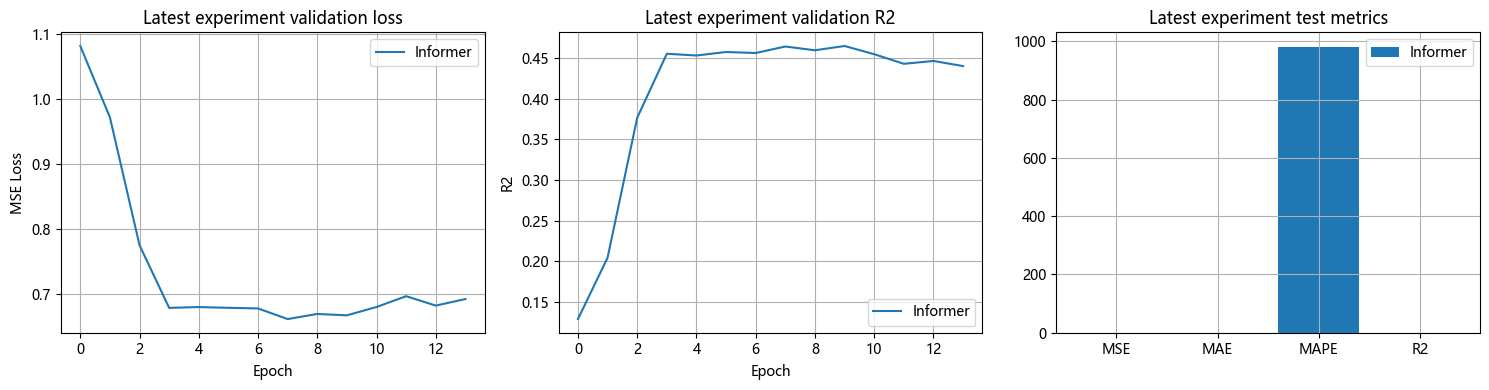


All result summary
--------------------------------------------------------------------------------------------------------------
key                              MSE          MAE          MAPE         R2           best_epoch  
--------------------------------------------------------------------------------------------------------------
ETTh1_h24_Informer               0.620657     0.556959     867.25       0.5144       4           
ETTh1_h48_Informer               0.613730     0.566630     982.33       0.5192       8           
--------------------------------------------------------------------------------------------------------------


In [22]:
if latest_combo_keys:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for key in latest_combo_keys:
        result = all_results[key]
        label = result['model']
        history = result['history']
        axes[0].plot(history['val_losses'], label=label)
        axes[1].plot(history['val_r2'], label=label)

    axes[0].set_title('Latest experiment validation loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].set_title('Latest experiment validation R2')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('R2')
    axes[1].legend()
    axes[1].grid(True)

    metric_names = ['MSE', 'MAE', 'MAPE', 'R2']
    x = np.arange(len(metric_names))
    width = 0.8 / max(1, len(latest_combo_keys))
    offset = -(len(latest_combo_keys) - 1) * width / 2

    for i, key in enumerate(latest_combo_keys):
        result = all_results[key]
        values = [result['metrics'][m] for m in metric_names]
        axes[2].bar(x + offset + i * width, values, width, label=result['model'])

    axes[2].set_title('Latest experiment test metrics')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(metric_names)
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

if all_results:
    print()
    print('All result summary')
    print('-' * 110)
    print(f'{"key":<32} {"MSE":<12} {"MAE":<12} {"MAPE":<12} {"R2":<12} {"best_epoch":<12}')
    print('-' * 110)
    for key, result in all_results.items():
        model_metrics = result['metrics']
        print(
            f'{key:<32} '
            f'{model_metrics["MSE"]:<12.6f} '
            f'{model_metrics["MAE"]:<12.6f} '
            f'{model_metrics["MAPE"]:<12.2f} '
            f'{model_metrics["R2"]:<12.4f} '
            f'{result["best_epoch"]:<12}'
        )
    print('-' * 110)


## 7. 单样本预测可视化

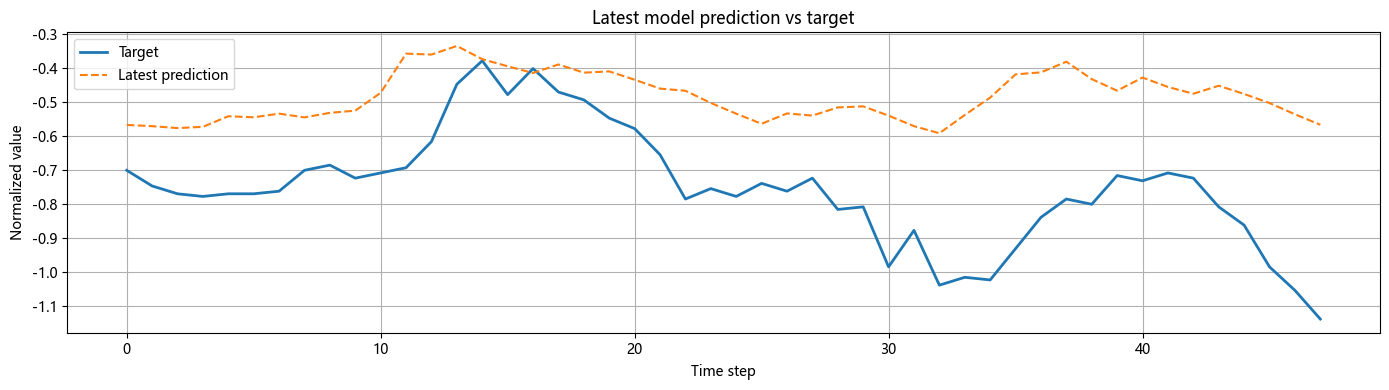

In [23]:
if latest_predictions is not None:
    sample_idx = 0
    n_steps = min(200, latest_horizon)

    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    ax.plot(latest_targets[sample_idx, :n_steps, latest_target_idx], label='Target', linewidth=2)
    ax.plot(latest_predictions[sample_idx, :n_steps, latest_target_idx], label='Latest prediction', linestyle='--')
    ax.set_title('Latest model prediction vs target')
    ax.set_xlabel('Time step')
    ax.set_ylabel('Normalized value')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()


## 8. 保存结果

In [24]:
print()
print('Saved result files')
if saved_paths:
    for key, path in saved_paths.items():
        print(f'{key}: {path}')
else:
    print('No results saved yet. Run the training cell first.')



Saved result files
ETTh1_h24_Informer: c:\Users\LOKER\Desktop\Research-Training\results\ETTh1_h24_Informer_results.npy
ETTh1_h48_Informer: c:\Users\LOKER\Desktop\Research-Training\results\ETTh1_h48_Informer_results.npy
